In [423]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import convolve
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from scipy.signal import butter, filtfilt

#fltré les signal
def lowpass_convolution_filter(signal, kernel_size=20):
    # Crée un noyau de moyenne glissante
    kernel = np.ones(kernel_size) / kernel_size
    # Applique la convolution avec mode 'same' pour garder la taille d'origine
    return convolve(signal, kernel, mode='same')



def butter_lowpass_filter(signal, cutoff=0.2, fs=1.0, order=3):
    b, a = butter(order, cutoff / (0.5 * fs), btype='low')
    return filtfilt(b, a, signal)


#normlisation des signal
def normalize_to_range(signal, a, b):
    return a + (signal - np.min(signal)) * (b - a) / (np.max(signal) - np.min(signal))

def normalize_01(signal):
    return (signal - np.min(signal)) / (np.max(signal) - np.min(signal))


#  Segmentation en fenêtres glissantes
def segment_signal(signal, window_size=140, step=70):
    segments = []
    for start in range(0, len(signal) - window_size + 1, step):
        segments.append(signal[start:start + window_size])
    return np.array(segments)





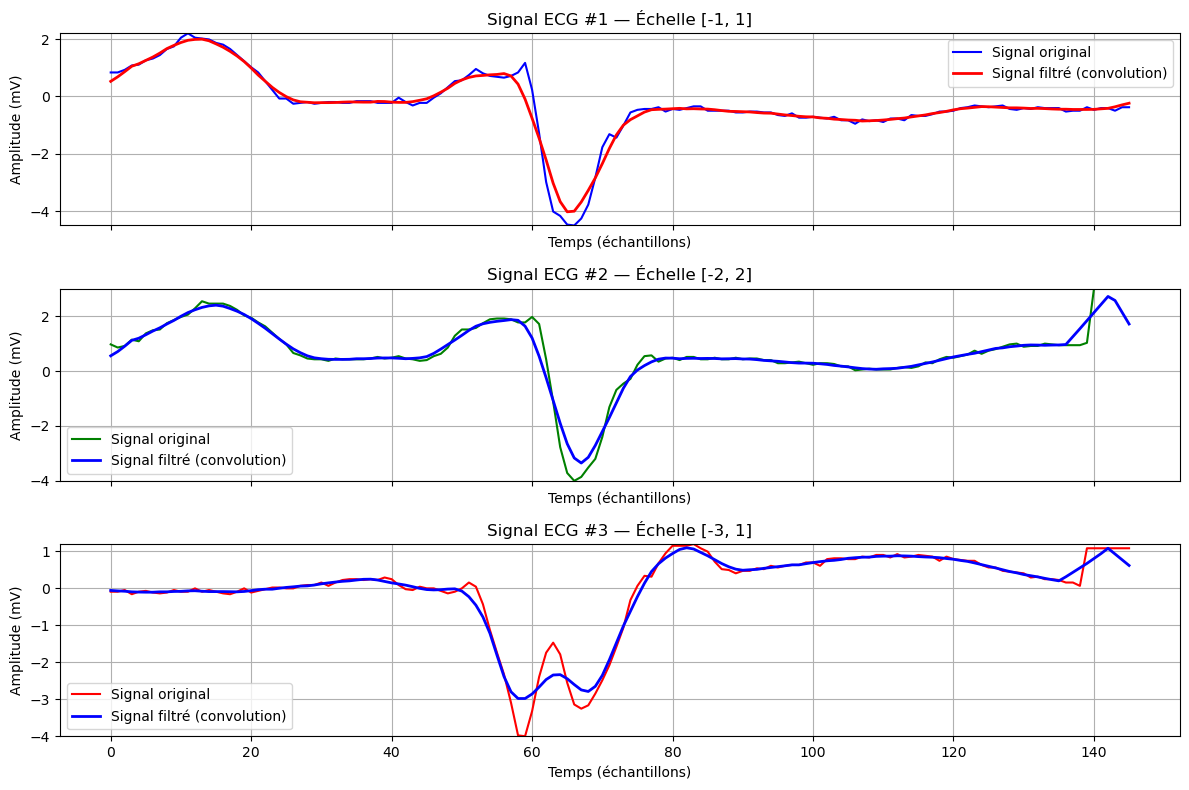

In [429]:
# === Chargement du fichier .mat contenant les signaux ECG ===
data = loadmat("ecg_dataset.mat")  # Remplace par le nom réel du fichier .mat

# Extraction des données
X = data['X']          # Tableau des signaux ECG (n_samples, n_points)
y = data['y'].flatten() # Labels associés à chaque signal (0 = normal, 1/2 = anomalie)

# === Sélection de trois signaux pour analyse individuelle ===
signal_1 = X[0]
signal_2 = X[1]
signal_3 = X[2]

# === Normalisation personnalisée selon l’échelle visuelle souhaitée ===
sig1_norm = normalize_to_range(signal_1, -4.5, 2.2)
sig2_norm = normalize_to_range(signal_2, -4, 3)
sig3_norm = normalize_to_range(signal_3, -4, 1.2)

# === Filtrage par convolution + normalisation entre 0 et 1 pour compatibilité avec l’autoencodeur ===
sig_filtred_1 = normalize_01(lowpass_convolution_filter(sig1_norm, kernel_size=7))
sig_filtred_2 = normalize_01(lowpass_convolution_filter(sig2_norm, kernel_size=7))
sig_filtred_3 = normalize_01(lowpass_convolution_filter(sig3_norm, kernel_size=7))

# === Visualisation des signaux originaux et filtrés ===
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# --- Signal 1 ---
axs[0].plot(sig1_norm, label="Signal original", color='blue')  # Avant filtrage
axs[0].plot(filtered_signal_1, label="Signal filtré (convolution)", color='red', linewidth=2)  # Après filtrage
axs[0].set_title("Signal ECG #1 — Échelle [-1, 1]")
axs[0].set_ylabel("Amplitude (mV)")
axs[0].set_xlabel("Temps (échantillons)")
axs[0].set_ylim(-4.5, 2.2)
axs[0].grid(True)
axs[0].legend()

# --- Signal 2 ---
axs[1].plot(sig2_norm, label="Signal original", color='green')
axs[1].plot(filtered_signal_2, label="Signal filtré (convolution)", color='blue', linewidth=2)
axs[1].set_title("Signal ECG #2 — Échelle [-2, 2]")
axs[1].set_xlabel("Temps (échantillons)")
axs[1].set_ylabel("Amplitude (mV)")
axs[1].set_ylim(-4, 3)
axs[1].grid(True)
axs[1].legend()

# --- Signal 3 ---
axs[2].plot(sig3_norm, label="Signal original", color='red')
axs[2].plot(filtered_signal_3, label="Signal filtré (convolution)", color='blue', linewidth=2)
axs[2].set_title("Signal ECG #3 — Échelle [-3, 1]")
axs[2].set_xlabel("Temps (échantillons)")
axs[2].set_ylabel("Amplitude (mV)")
axs[2].set_ylim(-4, 1.2)
axs[2].grid(True)
axs[2].legend()

# Affichage final des trois courbes
plt.tight_layout()
plt.show()

In [582]:


# Sélection des signaux normaux
X_N = X[y == 0]

# Prétraitement vectorisé : filtrage + normalisation + segmentation
segments_N = [
    segment_signal(
        normalize_01(
            lowpass_convolution_filter(
                normalize_to_range(sig, -4, 4), kernel_size=7
            )
        )
    )
    for sig in X_N
]

# Fusion de tous les segments en un seul tableau d'entraînement
X_train = np.concatenate(segments_N)



In [592]:
# === Définition de l'entrée du modèle ===
input_ecg = Input(shape=(140,))  # Un segment ECG de 140 points (fenêtre glissante)

# === Encodeur : compression progressive du signal ===
x = Dense(128, activation='relu')(input_ecg)  # Extraction initiale de caractéristiques
x = Dense(64, activation='relu')(x)           # Réduction de la dimension
x = Dense(32, activation='relu')(x)           # Espace latent compact (résume le segment)

# === Décodeur : reconstruction à partir de l'espace latent ===
x = Dense(64, activation='relu')(x)           # Expansion vers la reconstruction
x = Dense(128, activation='relu')(x)          # Approche de la taille d'origine
output_ecg = Dense(140, activation='sigmoid')(x)  # Reconstruction finale, normalisée entre 0 et 1

# === Création du modèle autoencodeur ===
autoencoder = Model(input_ecg, output_ecg)  # Modèle complet : entrée → reconstruction

# === Compilation du modèle ===
autoencoder.compile(optimizer=Adam(0.001), loss='mse')  # Optimisation par Adam, perte MSE (erreur quadratique)

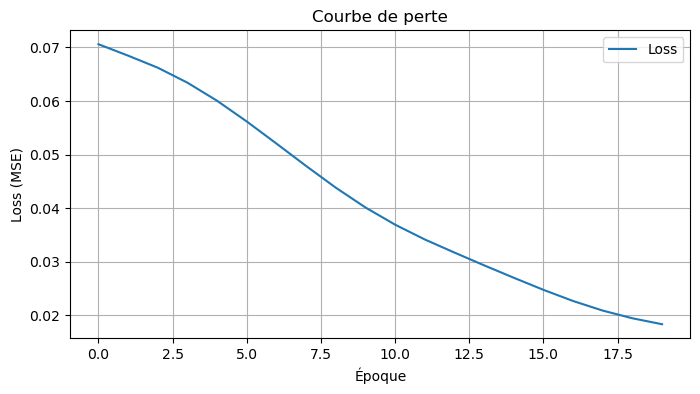

In [594]:
#Courbe de perte
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Loss')
plt.title("Courbe de perte")
plt.xlabel("Époque")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.legend()
plt.show()

In [617]:
# === Fusion des segments filtrés pour constituer l'ensemble d'entraînement ===
X_train = np.concatenate([segments_1, segments_2, segments_3])
# ⤷ On regroupe tous les segments issus des signaux 1, 2 et 3 (déjà filtrés et normalisés)
# ⤷ Chaque segment est une fenêtre glissante de 140 points

# === Entraînement de l'autoencodeur ===
history = autoencoder.fit(
    X_train,         # Données d'entrée (segments ECG)
    X_train,         # Cible = entrée (car autoencodeur non supervisé)
    epochs=20,       # Nombre d’époques d’apprentissage
    batch_size=32,   # Taille du lot (nombre de segments traités en parallèle)
    verbose=1        # Affichage du progrès pendant l'entraînement
)
# ⤷ Le modèle apprend à reconstruire les segments normaux
# ⤷ L’objectif est de minimiser l’erreur de reconstruction (MSE)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0049
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0046
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0043
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0040
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0038
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0035
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0034
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0032
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 0.0030
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0029
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0028
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0026
Epoch 13/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0025
Epoch 14/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0024
Epoch 15/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0023
Epoch 16/20
1/1 ━━━━━━━━━━━━━━━━━

In [639]:
# === Préparation des données de test ===
X_test = []
y_test = []

# Boucle sur tous les signaux du dataset
for i in range(len(X)):
    # Étape 1 : normalisation dans une plage [-4, 4]
    sig = normalize_to_range(X[i], -4, 4)

    # Étape 2 : filtrage par convolution pour lisser le signal
    sig = lowpass_convolution_filter(sig, kernel_size=7)

    # Étape 3 : normalisation entre 0 et 1 (compatible avec la sortie sigmoid du modèle)
    sig = normalize_01(sig)

    # Étape 4 : segmentation du signal en fenêtres glissantes
    segs = segment_signal(sig)

    # Ajout des segments au jeu de test
    X_test.extend(segs)

    # Réplication du label pour chaque segment
    y_test.extend([y[i]] * len(segs))

# Conversion en tableaux numpy
X_test = np.array(X_test)
y_test = np.array(y_test)

# === Reconstruction des segments par l’autoencodeur ===
X_reconstructed = autoencoder.predict(X_test)
# Le modèle tente de reconstruire chaque segment ECG

# === Calcul de l’erreur de reconstruction (MSE) pour chaque segment ===
errors = np.mean(np.square(X_test - X_reconstructed), axis=1)
# Plus l’erreur est élevée, plus le segment est suspect

# === Définition du seuil d’anomalie (95e percentile des erreurs) ===
threshold = np.percentile(errors, 95)
# Seuil choisi pour détecter les 5% de segments les plus mal reconstruits

# === Détection des anomalies : segments dont l’erreur dépasse le seuil ===
anomalies = errors > threshold

# === Affichage des résultats globaux ===
print(f" Seuil d’anomalie : {threshold:.4f}")
print(f" Nombre d’anomalies détectées : {np.sum(anomalies)} / {len(X_test)}")


169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step
 Seuil d’anomalie : 0.0184
 Nombre d’anomalies détectées : 271 / 5405


In [641]:
# === Récupération des classes présentes dans y_test ===
classes = np.unique(y_test)  # Extrait les classes distinctes (ex : [0, 1, 2])

# === Boucle sur chaque classe pour calculer l’erreur moyenne de reconstruction ===
for c in classes:
    indices = np.where(y_test == c)[0]  # Indices des segments appartenant à la classe c
    err_moyenne = np.mean(errors[indices])  # Moyenne des erreurs MSE pour cette classe
    print(f"Classe {c} — Erreur moyenne : {err_moyenne:.4f}")  # Affichage du résultat

Classe 0 — Erreur moyenne : 0.0062
Classe 1 — Erreur moyenne : 0.0194
Classe 2 — Erreur moyenne : 0.0411


In [643]:
# === Calcul de la précision ===
precision = precision_score(y_test > 0, anomalies, zero_division=0)
# y_test > 0 : segments réellement anormaux (classes 1 ou 2)
# anomalies : segments détectés comme anormaux par le modèle
#= Calcul du rappel ===
recall = recall_score(y_all > 0, anomalies, zero_division=0)
#  y_all > 0 : segments réellement anormaux dans l’ensemble complet (si différent de y_test)


# === Affichage des résultats ===
print(f" Seuil d’anomalie : {threshold:.4f}")  # Seuil utilisé pour classer un segment comme anormal
print(f" Précision : {precision:.2f}")         # Taux de vrais positifs parmi les segments détectés
print(f" Rappel    : {recall:.2f}")            # Taux de détection des segments réellement anormaux
print(f" Anomalies détectées : {np.sum(anomalies)} / {len(X_test)}")  # Nombre total de segments détectés comme anormaux

 Seuil d’anomalie : 0.0184
 Précision : 0.11
 Rappel    : 0.25
 Anomalies détectées : 271 / 5405


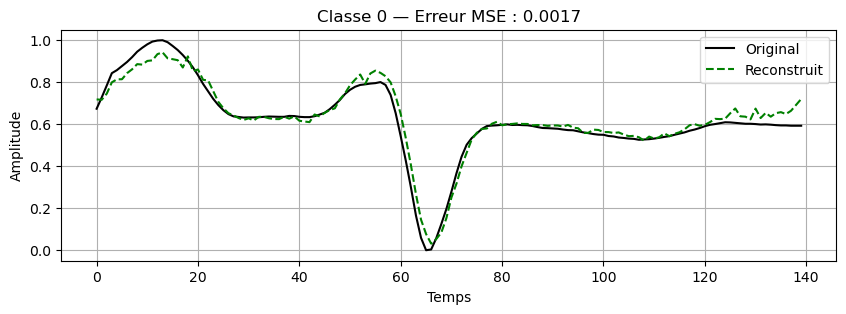

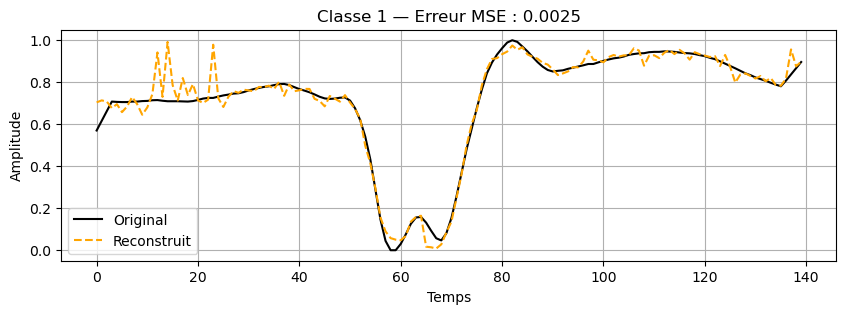

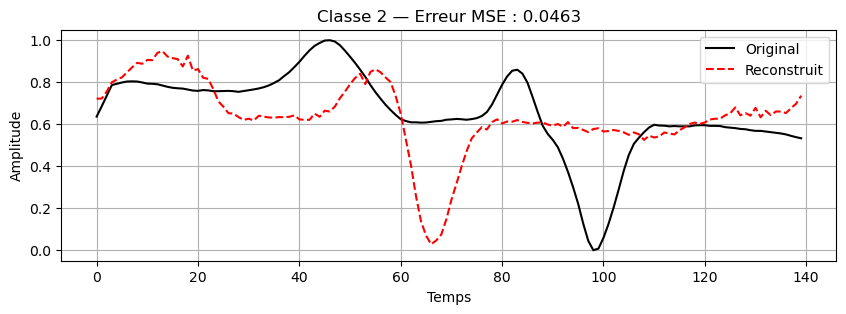

In [645]:
# === Définition des classes à visualiser et des couleurs associées ===
classes = [0, 1, 2]                  # 0 = normal, 1 = R (anomalie), 2 = V (anomalie)
colors = ['green', 'orange', 'red'] # Couleurs pour différencier visuellement les classes

# === Boucle sur chaque classe pour afficher un exemple de reconstruction ===
for c, col in zip(classes, colors):
    idx = np.where(y_test == c)[0][0]  # Récupère l’indice du premier segment appartenant à la classe c

    plt.figure(figsize=(10, 3))        # Crée une figure de taille adaptée

    # === Tracé du segment original ===
    plt.plot(X_test[idx], label="Original", color='black')

    # === Tracé du segment reconstruit par l’autoencodeur ===
    plt.plot(X_reconstructed[idx], label="Reconstruit", color=col, linestyle='--')

    # === Titre et légende ===
    plt.title(f"Classe {c} — Erreur MSE : {errors[idx]:.4f}")  # Affiche la classe et l’erreur de reconstruction
    plt.xlabel("Temps")                                        # Axe des abscisses : temps (échantillons)
    plt.ylabel("Amplitude")                                    # Axe des ordonnées : amplitude normalisée
    plt.legend()                                               # Affiche la légende des courbes
    plt.grid(True)                                             # Active la grille pour une meilleure lecture
    plt.show()                                                 # Affiche la figure

Faux positifs : 242
Faux négatifs : 88


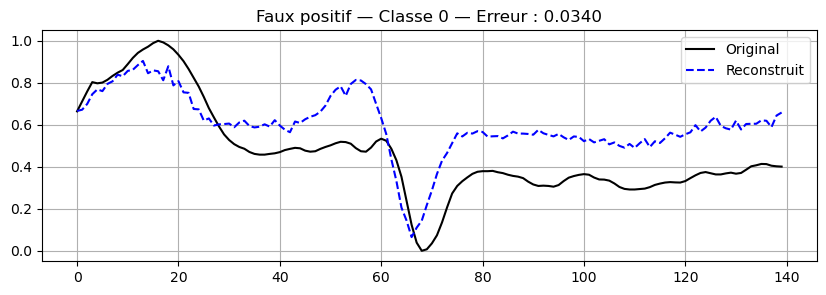

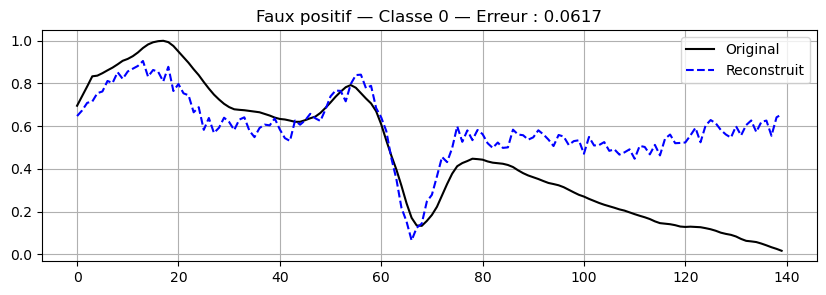

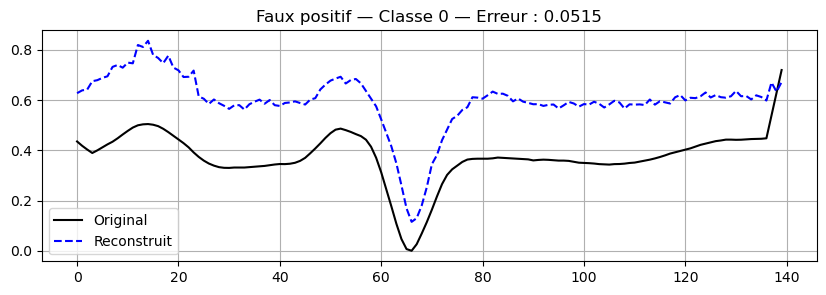

In [647]:
# === Identification des segments réellement anormaux ===
true_anomalies = y_test > 0
# Les classes 1 et 2 sont considérées comme anormales


# === Faux positifs : segments détectés comme anormaux mais qui sont normaux (classe 0) ===
faux_positifs = np.where((anomalies == 1) & (true_anomalies == 0))[0]
# Le modèle a signalé une anomalie (anomalies == 1)
#

# === Faux négatifs : segments réellement anormaux mais non détectés par le modèle ===
faux_negatifs = np.where((anomalies == 0) & (true_anomalies == 1))[0]
# Le modèle n’a pas détecté d’anomalie (anomalies == 0)
#  Mais le segment est en réalité anormal (true_anomalies == 1)

# === Affichage du nombre de faux positifs et faux négatifs ===
print(f"Faux positifs : {len(faux_positifs)}")
print(f"Faux négatifs : {len(faux_negatifs)}")

# === Visualisation des 3 premiers faux positifs ===
for i in faux_positifs[:3]:
    plt.figure(figsize=(10, 3))
    plt.plot(X_test[i], label="Original", color='black')              # Signal original
    plt.plot(X_reconstructed[i], label="Reconstruit", color='blue', linestyle='--')  # Reconstruction
    plt.title(f"Faux positif — Classe {y_test[i]} — Erreur : {errors[i]:.4f}")
    plt.legend()
    plt.grid(True)
    plt.show()

169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 767us/step


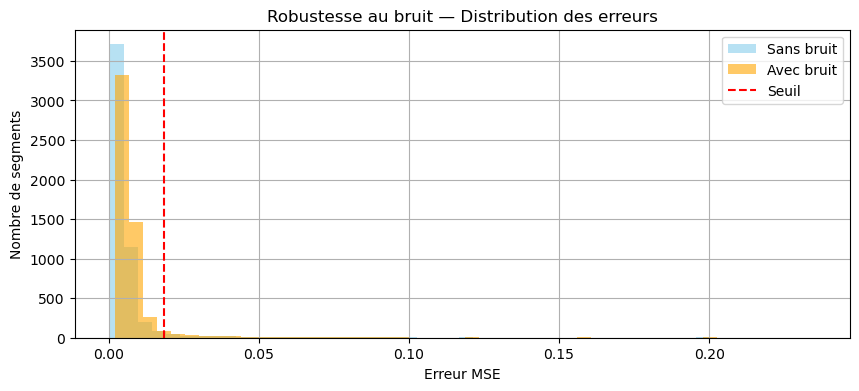

In [649]:
# === Ajout de bruit gaussien aux segments de test ===
X_noisy = X_test + np.random.normal(0, 0.05, X_test.shape)
# On ajoute un bruit aléatoire de moyenne 0 et d’écart-type 0.05
#  Cela simule des perturbations réalistes dans les signaux ECG

# === Calcul de l’erreur de reconstruction sur les signaux bruités ===
errors_noisy = np.mean(np.square(X_noisy - autoencoder.predict(X_noisy)), axis=1)
# On mesure l’erreur MSE entre les signaux bruités et leur reconstruction
# Cela permet de voir si le modèle reste fiable malgré le bruit

# === Visualisation comparative des erreurs avec et sans bruit ===
plt.figure(figsize=(10, 4))

# Histogramme des erreurs sans bruit
plt.hist(errors, bins=50, alpha=0.6, label="Sans bruit", color='skyblue')

# Histogramme des erreurs avec bruit
plt.hist(errors_noisy, bins=50, alpha=0.6, label="Avec bruit", color='orange')

# Ligne verticale indiquant le seuil d’anomalie
plt.axvline(threshold, color='red', linestyle='--', label='Seuil')

# Titres et légendes
plt.title("Robustesse au bruit — Distribution des erreurs")
plt.xlabel("Erreur MSE")
plt.ylabel("Nombre de segments")
plt.legend()
plt.grid(True)
plt.show()

In [652]:
df = pd.DataFrame({
    'Classe': y_test,
    'Erreur_MSE': errors,
    'Anomalie_detectée': anomalies.astype(int),
    'Faux_positif': [int(i in faux_positifs) for i in range(len(X_test))],
    'Faux_négatif': [int(i in faux_negatifs) for i in range(len(X_test))]
})
df.to_csv("analyse_erreurs_ecg.csv", index=False)
